# SVD - $W_O$ - GPT2

## Introduction

As part of this notebook I wish to conduct initial experiments into if its possible to extend the MLA Transformer adaption as suggested by DeepSeek for DeepSeek V2. In particular, I am looking to apply a latent projection to the output weights matrix $W_O$.

The main idea is to project each attention heads output into a smaller shared latent space. This reduces the number of parameters in the output projection and encourages the model to compress its information, which reduces redundancy across heads and promotes more efficient use of its representational capacity.

In order to establish if there is any potiential behind this idea, the first goal is to examine the $W_O$ weight matrics across the different layers and examine if we can approximate $W_O$ using some form of factorisation method (SVD). This notebook documents the factorisation of the $W_O$ matrices from the GPT2 model.

## Notebook Setup

In [1]:
! pip install -q transformers==4.57.5 torch==2.11.0 datasets==4.8.5 matplotlib==3.10.9 seaborn==0.13.2 


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


## Define the necessary libraries

In [2]:
# Base libraries
from safetensors import safe_open
import glob

# Maths
import numpy as np
import torch
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Transformers
from transformers import GPT2LMHeadModel

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Load the Bert Large Model

In [4]:
# Load model
model = GPT2LMHeadModel.from_pretrained("gpt2")

In [5]:
# Extract the WO weight matrices
W_outputs = []
for i, layer in enumerate(model.transformer.h):
    W_o = layer.attn.c_proj.weight.detach().cpu().numpy()
    W_outputs.append(W_o)

In [6]:
# Explore W
len(W_outputs)
W_outputs[0].shape

12

(768, 768)

## Apply SVD to each $W_O$ matrix

## Calculate the effective rank of each weight matrix

### Retension based rank (Energy Cutoff)

This is a threshold based matric, which focuses on the question, how many singular values do I need to preserve at least $x\%$ of the matrices total energy. This allows for the direct calculation of compressibility of a matrix.

In particular, in ML the singular value represents the stretch of each dimension, but S squared represents the energy (or variance) contained in that dimension.

In [7]:
def calculate_retension_based_rank(S, threshold_list):
    """
    This function take a matrices singular values and estimate the retension based rank for a list of thresholds.
    It essentially takes the singular values, squares them to represent each Wo dimensions variance and subsequently, calculates 
    the cumulative percentage energy values. Then taking the thresholds we find the number of dimensions that combine to cross the 
    pre-defined minimum thresholds.
    """

    # Calculate the cumulative percentage energy values -> Cumulative sum / total energy (S**2)
    cumulative_energy = np.cumsum(S**2) / np.sum(S**2)

    # Find smallest k such that cumulative energy >= alpha
    retention_based_rank_values = [{threshold: np.searchsorted(cumulative_energy, threshold) + 1} for threshold in threshold_list]

    return retention_based_rank_values

### Entropy based effective rank

Given singular values $S$ of a matrix $W$, we want to calculate the effective rank, such that:

- If the spectrum is uniform → rank is high
- If a few singular values dominate → rank is low
- If one singular value dominates → rank ≈ 1
- If all singular values are equal → rank = full rank

The entropy-based effective rank satisfies all of these.

In [8]:
def calculate_effective_rank(S):
    """
    Calculating the entropy based effective rank value. Remember that S**2 represents the energy of that dimension and thus we initially 
    calculate a energy based probability distribution which sums to 1. We then measure the uncertainty via the entropy calculation. We then
    convert back to a rank value by taking the exp.
    """

    # Calculate the energy based probability
    p = (S**2) / np.sum(S**2)

    # Calculate the Shannon entropy (log scale)
    H = -np.sum(p * np.log(p))
    
    # Calculate the effective rank (R scale)
    entropy_based_effective_rank = np.exp(H)

    return entropy_based_effective_rank

In [9]:
def calculate_SVD_rank_metrics(WO):
    """
    First calculate the SVD and then calculate the retension based rank value and entropy baesd effective rank values. 
    """

    # Create a list to store the results
    svd_layers = []
    
    # For each layers WO matrix
    for layer, wo in enumerate(WO):
    
        # Calculate the SVD
        U, S, VT = np.linalg.svd(wo, full_matrices=False)
    
        # Calculate the retension based rank values
        retension_based_rank_values = calculate_retension_based_rank(S, [0.99, 0.999])    
    
        # Calculate the entropy based effective rank
        entropy_based_effective_rank = calculate_effective_rank(S)
        
        # Store the results
        svd_layers.append({
            "layer": layer,
            "U": U,
            "S": S,
            "VT": VT,
            "retension_based_rank_values": retension_based_rank_values,
            "entropy_based_effective_rank": entropy_based_effective_rank,
        })

    return svd_layers

In [10]:
# Calculate the entropy based effective rank and also retention based rank values
svd_layers = calculate_SVD_rank_metrics(W_outputs)

In [11]:
# Convert to a dataframe
svd_layers_df = pd.DataFrame(svd_layers)

In [12]:
# Expand out the retensio based rank values
svd_layers_df_expanded = pd.concat([
    svd_layers_df.drop(columns='retension_based_rank_values'),
    svd_layers_df['retension_based_rank_values'].apply(lambda lst: {k: v for d in lst for k, v in d.items()}).apply(pd.Series)
], axis=1)

In [13]:
# Rename the columns
svd_layers_df_expanded = svd_layers_df_expanded.rename(columns={0.99: 'r99', 0.999: 'r99.9'})


## Plot the curves of the retension based rank values

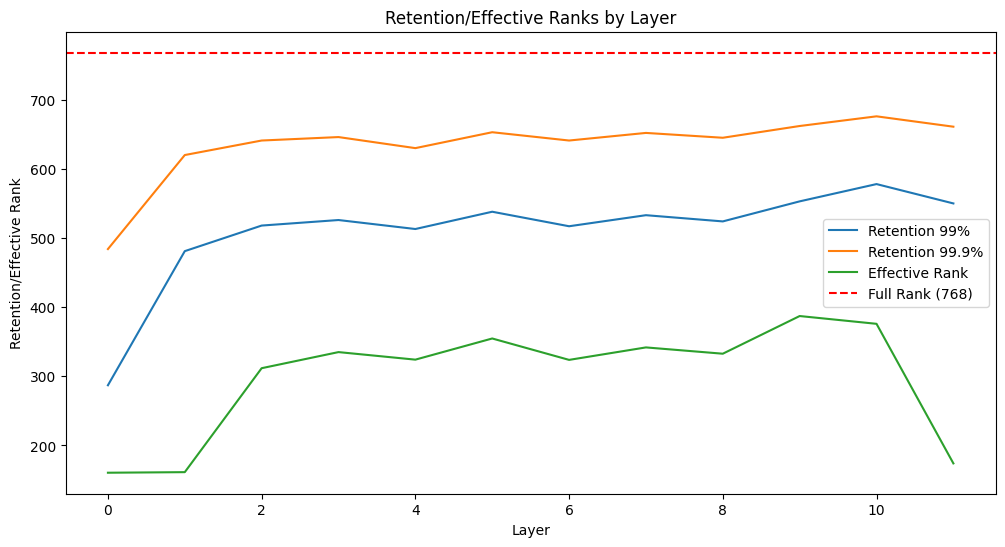

In [14]:
# Plot the  
ax = svd_layers_df_expanded.plot(x='layer', y=['r99', 'r99.9', 'entropy_based_effective_rank'], figsize=(12, 6))

# Add a custom horizontal line
_ = plt.axhline(y=W_outputs[0].shape[0], color='red', linestyle='--', label='Threshold Line')

# Add titles, labels and legend
_ = plt.ylabel('Retention/Effective Rank')
_ = plt.xlabel('Layer')
_ = plt.title('Retention/Effective Ranks by Layer')
_ = ax.legend(['Retention 99%', 'Retention 99.9%', "Effective Rank", f"Full Rank ({W_outputs[0].shape[0]})"])
plt.show()

## Calculate the average value across the different layers

In [15]:
# Calculate and print with 2-digit precision
print(f"Average Retention 99%: {svd_layers_df_expanded['r99'].mean():.2f}")
print(f"Average Retention 99.9%: {svd_layers_df_expanded['r99.9'].mean():.2f}")
print(f"Average Effective Rank (Entropy): {svd_layers_df_expanded['entropy_based_effective_rank'].mean():.2f}")

Average Retention 99%: 509.83
Average Retention 99.9%: 634.25
Average Effective Rank (Entropy): 298.52


## Conclusion
From this plot I can confirm that I believe the GPT2 models output projection matrix $W_O$ is also moderately overparameterised and even has more redundant parameters than compared to the BERT model. This suggests that the GPT2 model is even lazier when it has even fewer parameters than BERT Large (768 vs 1024). The fact that the Effective Rank is so far below even the 99% line suggests that many of the dimensions the model is using are highly correlated or redundant.